In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# MNIST veri setini indiriyoruz (el yazısı rakamlar)
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Veriyi 0-1 arasına normalize ediyoruz (Önemli mühendislik adımı!)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# 28x28 piksellik resimleri 784 boyutlu tek bir satıra (vektöre) çeviriyoruz
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print("Veriler başarıyla yüklendi ve hazırlandı!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Veriler başarıyla yüklendi ve hazırlandı!


In [4]:
# Girdi boyutu (28*28 = 784)
input_img = layers.Input(shape=(784,))

# ENCODER: Veriyi 32 boyuta sıkıştırıyoruz (Latent Space)
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(32, activation='relu')(encoded) # İşte o meşhur darboğaz!

# DECODER: 32 boyuttan tekrar 784 boyuta geri inşa ediyoruz
decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

# Modeli birleştirme
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Model özetini göster (DİKKAT: Buranın SS'ini alacaksın!)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Modeli eğitiyoruz
history = autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

print("Eğitim tamamlandı!")

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0606 - val_loss: 0.0327
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0259 - val_loss: 0.0208
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0192 - val_loss: 0.0170
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0164 - val_loss: 0.0149
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0147 - val_loss: 0.0137
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0136 - val_loss: 0.0128
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0129 - val_loss: 0.0123
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0124 - val_loss: 0.0119
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0120 - val_loss: 0.0115
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0117 - val_loss: 0.0112
Eğitim tamamlandı!


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step


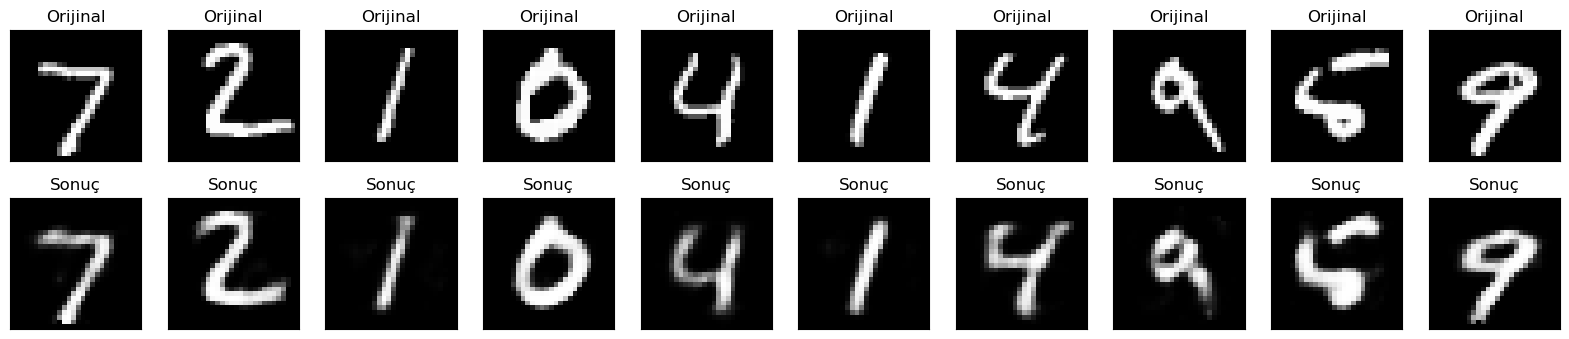

In [6]:
# Test verisinden 10 tane örnek rakam seçip tahmin yürütüyoruz
decoded_imgs = autoencoder.predict(x_test)

n = 10  # Gösterilecek rakam sayısı
plt.figure(figsize=(20, 4))
for i in range(n):
    # ÜST SATIR: Orijinal Görüntü
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Orijinal")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # ALT SATIR: Senin modelinin 32 boyuttan geri ürettiği (Reconstructed)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Sonuç")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [7]:
# Modelin tamamını bir dosya olarak kaydediyoruz
autoencoder.save('mnist_autoencoder_model.h5')
print("Modelin beyni 'mnist_autoencoder_model.h5' adıyla kaydedildi!")

Modelin beyni 'mnist_autoencoder_model.h5' adıyla kaydedildi!
